In [19]:
from lh5 import read, read_as, ls, show
from dspeed.vis import WaveformBrowser
from dspeed import units
from dspeed import build_dsp
import numpy as np
import matplotlib.pyplot as plt
import os
import lh5
# from legendtestdata import LegendTestData
data_file = "/mnt/atlas01/projects/scarf/data/sp01/prodenv/ref-raw/generated/tier/raw/cal/p00/r037/sp01-p00-r037-cal-20231026T180002Z-tier_raw.lh5"

# ldata = LegendTestData()
# data_file = lda.get_path("lh5/LDQTA_r117_20200110T105115Z_cal_geds_raw.lh5")

# plt.rcParams["figure.figsize"] = (14, 4)
# plt.rcParams["figure.facecolor"] = "white"
# plt.rcParams["font.size"] = 12


In [9]:
from pytools4scarf.utils import minmax, load_yaml
dsp_config = load_yaml("/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/ged_dsp_conf.yaml")

Found waveforms dict_keys(['waveform_presummed', 'waveform_windowed']). Use the lines argument to select one or more.


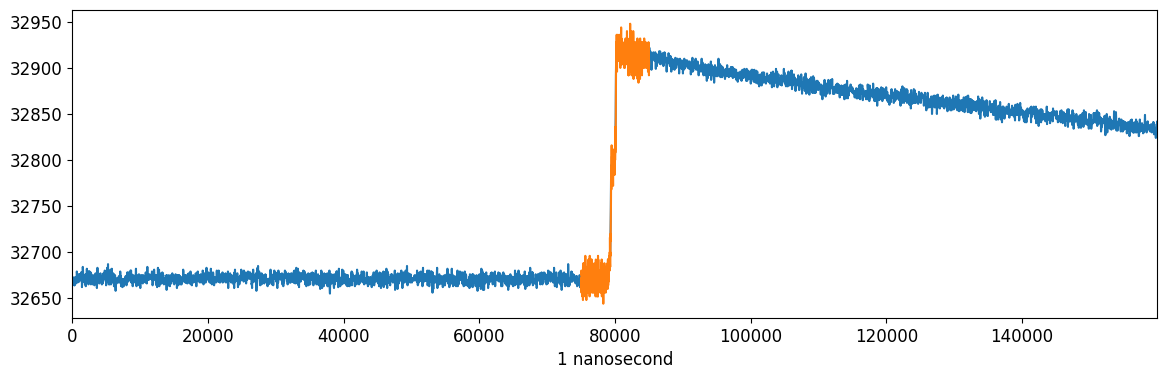

In [ ]:

entry_no = 7  # which waveform in our example data_file to use for plotting
browser = WaveformBrowser(
    data_file,
    "ch002/raw",
    
)

dsp_config["outputs"].extend(["wf_blsub", "wf_pz", "wf_single_pz", "wf_blsub_win", "wf_pz_win", "wf_single_pz_win",
                              "wf_etrap", "wf_etrap_fix", "wf_atrap_win", "tp_start",
                              "curr_win", "curr_up_win", "curr_av_win", "wf_tri", "wf_mwavg_win", "wf_mwavg_up_win", "wf_mwavg_up_curr_win",
                              "Iasy_threshold"
                              ])
dsp_config["processors"]["wf_single_pz"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub", "db.pz.tau1", "wf_single_pz"],
    "unit": "ADC",
}
dsp_config["processors"]["wf_single_pz_win"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub_win", "db.pz.tau1", "wf_single_pz_win"],
    "unit": "ADC",
}
browser.draw_entry(entry_no)

In [17]:
ts_presummed_values = np.arange(0, 160, 0.04)
ts_windowed_values = np.linspace(75, 85, 1001)

In [21]:
raw_df = lh5.read(name="ch002/raw",
               lh5_file=data_file,
            #    n_rows=100
               ).view_as("pd")

Text(0, 0.5, 'ADC channels (a.u.)')

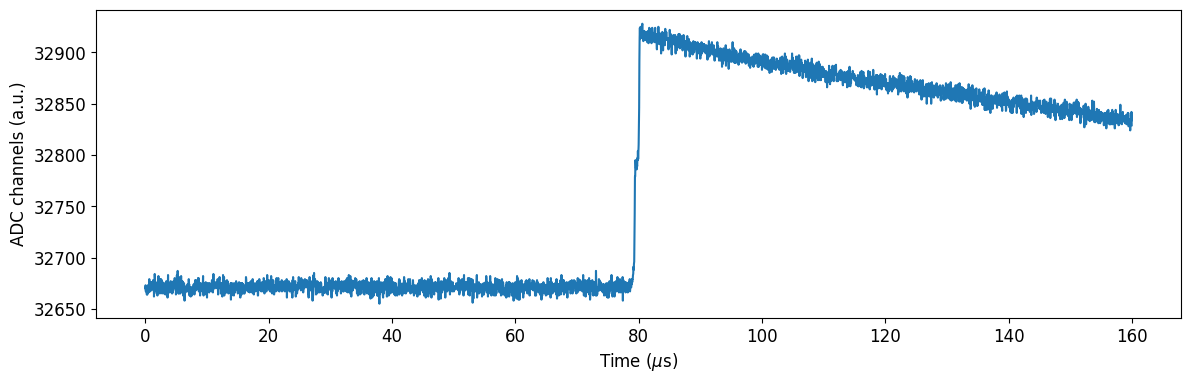

In [23]:
fig, ax = plt.subplots()

i=7

ax.plot(ts_presummed_values, raw_df.waveform_presummed_values[i])
ax.set_xlabel(r"Time ($\mu$s)")
ax.set_ylabel("ADC channels (a.u.)")